# Projective Baseline LLF Convexity Analysis

This experiment compares real sentence linearizations against random projective baselines across UD treebanks stratified by WALS word order, language family, and size. IMB profiles are computed and verified via the total_IMB identity. Metrics include max_imb, mean_imb, LLF, and parametric convexity costs at multiple alpha exponents. Regression-based residualization controls for dependency distance (DD) moments and tree properties.

**Key finding**: R-squared of cost from DD features monotonically decreases across alpha, showing temporal overlap contributes beyond DD alone at higher convexity exponents.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python>=3.11 (Colab); fall back to latest compatible
    try:
        _pip('scipy==1.16.3')
    except Exception:
        _pip('scipy')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


ERROR: Ignored the following versions that require a different python version: 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.11; 1.16.3 Requires-Python >=3.11; 1.17.0 Requires-Python >=3.11; 1.17.0rc1 Requires-Python >=3.11; 1.17.0rc2 Requires-Python >=3.11; 1.17.1 Requires-Python >=3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10
ERROR: Could not find a version that satisfies the requirement scipy==1.16.3 (from versions: 0.8.0, 0.9.0, 0.10.0, 0.10.1, 0.11.0, 0.12.0, 0.12.1, 0.13.0, 0.13.1, 0.13.2, 0.13.3, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.17.0, 0.17.1, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 1.0.0, 1.0.1, 1.1.0, 1.2.0, 1.2.1, 1.2.2, 1.2.3, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.4.0, 1.4.1, 1.5.0, 1.5.1, 1.5.2, 1.5.3, 1.5.4, 1.6.0, 1.6.1, 1.7.2, 1.7.3, 1.8.0rc1, 1.8.0rc2, 1.8.0rc3, 1


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
import time
import random
from collections import defaultdict

import numpy as np
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e4150b-head-directionality-dependent-temporal-d/main/experiment_iter2_projective_base/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['treebanks'])} treebanks:")
for tb_id, tb in data['treebanks'].items():
    print(f"  {tb_id}: {tb['language']} ({tb['word_order']}), {len(tb['sentences'])} sentences")

Loaded 5 treebanks:
  ar_padt: Standard Arabic (VSO), 20 sentences
  de_gsd: German (No dominant order), 20 sentences
  en_ewt: English (SVO), 20 sentences
  ja_gsd: Japanese (SOV), 20 sentences
  zh_gsd: Mandarin Chinese (SVO), 20 sentences


## Configuration

All tunable parameters are defined here. Starting with minimum values for fast demo execution.

In [5]:
# Convexity exponents to test
ALPHAS = [1.0, 1.2, 1.5, 2.0, 3.0]  # original: [1.0, 1.2, 1.5, 2.0, 3.0]

# Number of random projective baselines per sentence
N_BASELINES = 100  # original: 100

# Maximum sentences per treebank (use all available in demo data)
MAX_SENTENCES = 20  # original: 500

# Reproducibility
random.seed(42)
np.random.seed(42)
sys.setrecursionlimit(5000)

print(f"Config: ALPHAS={ALPHAS}, N_BASELINES={N_BASELINES}, MAX_SENTENCES={MAX_SENTENCES}")

Config: ALPHAS=[1.0, 1.2, 1.5, 2.0, 3.0], N_BASELINES=100, MAX_SENTENCES=20


## Core: IMB Profile Computation

The IMB (Intervention-based Memory Burden) profile measures temporal memory load at each word position. `IMB(j)` = sum of ages of all open dependencies at position `j`. We also verify the total_IMB identity: `sum(IMB) == sum(d*(d+1)/2)` for all dependency distances `d`.

In [6]:
def compute_imb_profile(heads: list[int]) -> list[float]:
    """Compute IMB profile from heads array (1-indexed, 0=root).

    IMB(j) = sum of ages of all open dependencies at position j.
    An open dependency from dep_pos to head_pos has age = j - span_start at position j.
    """
    n = len(heads)
    imb = [0.0] * n
    for i in range(n):
        h = heads[i]
        if h == 0:
            continue
        dep_pos = i + 1
        head_pos = h
        s = min(dep_pos, head_pos)
        e = max(dep_pos, head_pos)
        for j in range(s, e + 1):
            imb[j - 1] += (j - s)
    return imb


def verify_identity(imb_profile: list[float], dd_list: list[int]) -> tuple[bool, float, float]:
    """Verify total_imb == sum(d*(d+1)/2 for d in dd_list)."""
    total_imb = sum(imb_profile)
    expected = sum(d * (d + 1) / 2.0 for d in dd_list)
    return abs(total_imb - expected) < 1e-6, total_imb, expected


# Quick test
heads_a = [0, 1, 2, 2, 3]
imb_a = compute_imb_profile(heads_a)
dd_a = [abs(i + 1 - heads_a[i]) for i in range(5) if heads_a[i] != 0]
ok_a, _, _ = verify_identity(imb_a, dd_a)
print(f"Test Tree A: IMB={imb_a}, identity_ok={ok_a}")

Test Tree A: IMB=[0.0, 1.0, 2.0, 3.0, 2.0], identity_ok=True


## Core: Projective Baseline Generation

Generate random projective linearizations of a dependency tree. Each baseline preserves the tree structure but randomly assigns dependents to left or right of their head, producing a valid projective ordering.

In [7]:
def build_tree(heads: list[int]) -> tuple[int, dict]:
    """Build tree from heads (1-indexed, 0=root). Returns (root_0idx, children_dict)."""
    children = defaultdict(list)
    root = None
    for i, h in enumerate(heads):
        if h == 0:
            if root is None:
                root = i
        else:
            children[h - 1].append(i)
    return root, dict(children)


def random_projective_linearization(node: int, children_dict: dict) -> list[int]:
    """Recursively generate a random projective linearization of the subtree."""
    kids = children_dict.get(node, [])
    if not kids:
        return [node]

    left_kids, right_kids = [], []
    for kid in kids:
        if random.random() < 0.5:
            left_kids.append(kid)
        else:
            right_kids.append(kid)

    random.shuffle(left_kids)
    random.shuffle(right_kids)

    result = []
    for kid in left_kids:
        result.extend(random_projective_linearization(kid, children_dict))
    result.append(node)
    for kid in right_kids:
        result.extend(random_projective_linearization(kid, children_dict))
    return result


def generate_baseline_heads(heads: list[int]) -> list[int] | None:
    """Generate a random projective baseline linearization, returning new heads array."""
    n = len(heads)
    root, children = build_tree(heads)
    if root is None:
        return None

    lin_order = random_projective_linearization(root, children)
    if len(lin_order) != n:
        return None

    # Map old node index -> new 1-indexed position
    pos_map = [0] * n
    for new_pos, old_node in enumerate(lin_order):
        pos_map[old_node] = new_pos + 1

    new_heads = [0] * n
    for old_node in range(n):
        old_head = heads[old_node]
        new_pos = pos_map[old_node]
        if old_head == 0:
            new_heads[new_pos - 1] = 0
        else:
            new_heads[new_pos - 1] = pos_map[old_head - 1]
    return new_heads


# Quick test
test_heads = [2, 0, 2, 5, 2]
bh = generate_baseline_heads(test_heads)
print(f"Original heads: {test_heads}")
print(f"Baseline heads: {bh}")

Original heads: [2, 0, 2, 5, 2]
Baseline heads: [2, 4, 4, 0, 4]


## Process Sentences

For each sentence, compute the real IMB metrics (max_imb, mean_imb, LLF, parametric convexity costs) and compare against `N_BASELINES` random projective baselines.

In [8]:
def process_sentence(sent: dict, n_baselines: int, alphas: list[float]) -> dict | None:
    """Process a single sentence: compute real IMB metrics + projective baselines."""
    heads = sent["heads"]
    dd_list = sent["dd_list"]
    n = len(heads)
    if n < 3:
        return None

    # Real IMB
    real_imb = compute_imb_profile(heads)
    ok, total_imb, expected = verify_identity(real_imb, dd_list)

    real_arr = np.array(real_imb)
    real_max = float(np.max(real_arr))
    real_mean = float(np.mean(real_arr))
    real_llf = real_mean / real_max if real_max > 0 else 1.0

    real_alpha_costs = {}
    for a in alphas:
        real_alpha_costs[f"{a:.1f}"] = float(np.sum(np.power(real_arr, a)))

    # Generate baselines
    b_maxs, b_means, b_llfs = [], [], []
    b_alpha_costs = {f"{a:.1f}": [] for a in alphas}

    for _ in range(n_baselines):
        bh = generate_baseline_heads(heads)
        if bh is None:
            continue
        b_imb = compute_imb_profile(bh)
        b_arr = np.array(b_imb)
        bmax = float(np.max(b_arr))
        bmean = float(np.mean(b_arr))
        b_maxs.append(bmax)
        b_means.append(bmean)
        b_llfs.append(bmean / bmax if bmax > 0 else 1.0)
        for a in alphas:
            b_alpha_costs[f"{a:.1f}"].append(float(np.sum(np.power(b_arr, a))))

    if len(b_maxs) < 3:
        return None

    result = {
        "sent_id": sent["sent_id"],
        "sentence_length": sent["sentence_length"],
        "tree_depth": sent["tree_depth"],
        "mean_arity": sent["mean_arity"],
        "mean_dd": sent["mean_dd"],
        "dd_variance": sent["dd_variance"],
        "dd_skewness": sent["dd_skewness"],
        "projectivity_proportion": sent["projectivity_proportion"],
        "mean_ic": sent["mean_ic"],
        "ic_variance": sent["ic_variance"],
        "max_ic": sent["max_ic"],
        "identity_ok": ok,
        "identity_error": abs(total_imb - expected),
        "real_max_imb": real_max,
        "real_mean_imb": real_mean,
        "real_llf": real_llf,
        "baseline_mean_max_imb": float(np.mean(b_maxs)),
        "baseline_std_max_imb": float(np.std(b_maxs)),
        "baseline_mean_llf": float(np.mean(b_llfs)),
        "baseline_std_llf": float(np.std(b_llfs)),
        "baseline_mean_mean_imb": float(np.mean(b_means)),
        "n_valid_baselines": len(b_maxs),
    }
    for a in alphas:
        akey = f"{a:.1f}"
        result[f"real_cost_{akey}"] = real_alpha_costs[akey]
        result[f"baseline_mean_cost_{akey}"] = float(np.mean(b_alpha_costs[akey]))
        result[f"baseline_std_cost_{akey}"] = float(np.std(b_alpha_costs[akey]))

    return result

print("process_sentence defined.")

process_sentence defined.


## Run Processing on All Treebanks

Process each treebank's sentences sequentially. For each treebank, compute per-sentence IMB metrics and baseline comparisons, then collect results with identity violation tracking.

In [9]:
t0 = time.time()

all_tb_results = {}
total_violations = 0

for tb_id, tb_data in data["treebanks"].items():
    sentences = tb_data["sentences"][:MAX_SENTENCES]

    # Deterministic seed per treebank
    rng_seed = sum(ord(c) * (i + 1) for i, c in enumerate(tb_id)) % (2**31)
    random.seed(rng_seed)
    np.random.seed(rng_seed % (2**32))

    results = []
    n_violations = 0
    for sent in sentences:
        try:
            r = process_sentence(sent, N_BASELINES, ALPHAS)
            if r is not None:
                results.append(r)
                if not r["identity_ok"]:
                    n_violations += 1
        except Exception:
            continue

    all_tb_results[tb_id] = results
    total_violations += n_violations

    rl = np.mean([r["real_llf"] for r in results]) if results else 0
    bl = np.mean([r["baseline_mean_llf"] for r in results]) if results else 0
    print(f"  {tb_id}: n={len(results)}, real_LLF={rl:.3f}, base_LLF={bl:.3f}, diff={rl-bl:+.4f}")

elapsed = time.time() - t0
total_sents = sum(len(v) for v in all_tb_results.values())
print(f"\nProcessed {total_sents} sentences across {len(all_tb_results)} treebanks in {elapsed:.1f}s")
print(f"Identity violations: {total_violations}")

  ar_padt: n=20, real_LLF=0.577, base_LLF=0.450, diff=+0.1272
  de_gsd: n=20, real_LLF=0.411, base_LLF=0.444, diff=-0.0326


  en_ewt: n=20, real_LLF=0.444, base_LLF=0.431, diff=+0.0125


  ja_gsd: n=20, real_LLF=0.439, base_LLF=0.434, diff=+0.0043
  zh_gsd: n=20, real_LLF=0.410, base_LLF=0.428, diff=-0.0181

Processed 100 sentences across 5 treebanks in 0.4s
Identity violations: 0


## Regression-Based Residualization

Regress the real-vs-baseline differences on DD moments and tree properties. The residuals represent the portion of the difference NOT explained by dependency distance alone. The key test: R-squared of cost from DD features should decrease with alpha, showing temporal overlap contributes beyond DD at higher convexity exponents.

In [10]:
def ols_regression(X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    """OLS regression with intercept. Returns (beta, residuals, R^2)."""
    n = X.shape[0]
    X_int = np.column_stack([np.ones(n), X])
    beta, _, _, _ = np.linalg.lstsq(X_int, y, rcond=None)
    y_pred = X_int @ beta
    resid = y - y_pred
    ss_res = float(np.sum(resid**2))
    ss_tot = float(np.sum((y - np.mean(y))**2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0
    return beta, resid, r2


def residualize_all(all_results: list[dict], alphas: list[float]) -> dict:
    """Residualize real-baseline differences controlling for DD moments + tree properties."""
    X = np.array([
        [r["mean_dd"], r["dd_variance"], r["dd_skewness"],
         r["sentence_length"], r["tree_depth"], r["mean_arity"],
         r["projectivity_proportion"]]
        for r in all_results
    ])

    out = {}

    # LLF difference
    diff_llf = np.array([r["real_llf"] - r["baseline_mean_llf"] for r in all_results])
    beta_l, resid_l, r2_l = ols_regression(X, diff_llf)
    out["llf"] = {"r2_diff": r2_l, "beta": beta_l.tolist(), "resid_diff": resid_l}

    y_real_llf = np.array([r["real_llf"] for r in all_results])
    _, _, r2_llf_level = ols_regression(X, y_real_llf)
    out["llf"]["r2_level"] = r2_llf_level

    # max_imb difference
    diff_max = np.array([r["real_max_imb"] - r["baseline_mean_max_imb"] for r in all_results])
    beta_m, resid_m, r2_m = ols_regression(X, diff_max)
    out["max_imb"] = {"r2_diff": r2_m, "beta": beta_m.tolist(), "resid_diff": resid_m}

    y_real_max = np.array([r["real_max_imb"] for r in all_results])
    _, _, r2_max_level = ols_regression(X, y_real_max)
    out["max_imb"]["r2_level"] = r2_max_level

    # Alpha cost differences
    for alpha in alphas:
        akey = f"{alpha:.1f}"
        diff_c = np.array([
            r[f"real_cost_{akey}"] - r[f"baseline_mean_cost_{akey}"]
            for r in all_results
        ])
        beta_c, resid_c, r2_c = ols_regression(X, diff_c)
        out[f"cost_{akey}"] = {"r2_diff": r2_c, "beta": beta_c.tolist(), "resid_diff": resid_c}

        # R^2 of cost level from DD features only (for negative control)
        y_real_cost = np.array([r[f"real_cost_{akey}"] for r in all_results])
        X_dd = X[:, :3]  # mean_dd, dd_variance, dd_skewness only
        _, _, r2_cost_dd = ols_regression(X_dd, y_real_cost)
        out[f"cost_{akey}"]["r2_cost_from_dd"] = r2_cost_dd

    return out


# Flatten all sentence results with treebank tracking
all_sentence_results = []
tb_indices = {}
for tb_id in sorted(all_tb_results.keys()):
    res = all_tb_results[tb_id]
    if not res:
        continue
    start = len(all_sentence_results)
    all_sentence_results.extend(res)
    tb_indices[tb_id] = (start, len(all_sentence_results))

print(f"Total sentences for residualization: {len(all_sentence_results)}")

# Run residualization
resid = residualize_all(all_sentence_results, ALPHAS)

print(f"R^2 LLF level from features: {resid['llf']['r2_level']:.4f}")
print(f"R^2 LLF diff from features:  {resid['llf']['r2_diff']:.4f}")
for alpha in ALPHAS:
    akey = f"{alpha:.1f}"
    print(f"  alpha={akey}: R^2 cost from DD={resid[f'cost_{akey}']['r2_cost_from_dd']:.4f}")

Total sentences for residualization: 100
R^2 LLF level from features: 0.2997
R^2 LLF diff from features:  0.2778
  alpha=1.0: R^2 cost from DD=0.9419
  alpha=1.2: R^2 cost from DD=0.9357
  alpha=1.5: R^2 cost from DD=0.9029
  alpha=2.0: R^2 cost from DD=0.7943
  alpha=3.0: R^2 cost from DD=0.5246


## Per-Treebank Statistics & Aggregate Results

Compute paired statistics (Cohen's d, t-tests) for each treebank on both raw and residualized metrics, then aggregate across all treebanks with word-order breakdowns and monotonicity verification.

In [11]:
def _safe_cohen_d(diff: np.ndarray) -> float:
    """Compute Cohen's d = mean(diff)/std(diff) safely."""
    sd = float(np.std(diff, ddof=1)) if len(diff) > 1 else 0.0
    return float(np.mean(diff)) / sd if sd > 1e-12 else 0.0


def _safe_ttest(a: np.ndarray, b: np.ndarray) -> tuple[float, float]:
    """Paired t-test with NaN handling."""
    if len(a) < 3:
        return 0.0, 1.0
    try:
        t, p = scipy_stats.ttest_rel(a, b)
        return float(t) if not np.isnan(t) else 0.0, float(p) if not np.isnan(p) else 1.0
    except Exception:
        return 0.0, 1.0


def _safe_ttest_1samp(a: np.ndarray) -> tuple[float, float]:
    """One-sample t-test against 0."""
    if len(a) < 3:
        return 0.0, 1.0
    try:
        t, p = scipy_stats.ttest_1samp(a, 0)
        return float(t) if not np.isnan(t) else 0.0, float(p) if not np.isnan(p) else 1.0
    except Exception:
        return 0.0, 1.0


def compute_treebank_stats(tb_results, resid_data, idx_start, idx_end, alphas):
    """Compute paired statistics for one treebank."""
    real_llfs = np.array([r["real_llf"] for r in tb_results])
    base_llfs = np.array([r["baseline_mean_llf"] for r in tb_results])
    raw_diff = real_llfs - base_llfs
    _, raw_p = _safe_ttest(real_llfs, base_llfs)

    resid_llf = resid_data["llf"]["resid_diff"][idx_start:idx_end]
    _, resid_llf_p = _safe_ttest_1samp(resid_llf)

    real_maxs = np.array([r["real_max_imb"] for r in tb_results])
    base_maxs = np.array([r["baseline_mean_max_imb"] for r in tb_results])
    _, raw_max_p = _safe_ttest(real_maxs, base_maxs)

    resid_max = resid_data["max_imb"]["resid_diff"][idx_start:idx_end]
    _, resid_max_p = _safe_ttest_1samp(resid_max)

    convexity = {}
    for alpha in alphas:
        akey = f"{alpha:.1f}"
        rc = np.array([r[f"real_cost_{akey}"] for r in tb_results])
        bc = np.array([r[f"baseline_mean_cost_{akey}"] for r in tb_results])
        raw_c_diff = rc - bc
        _, raw_c_p = _safe_ttest(rc, bc)
        resid_c = resid_data[f"cost_{akey}"]["resid_diff"][idx_start:idx_end]
        _, resid_c_p = _safe_ttest_1samp(resid_c)
        convexity[f"alpha_{akey}"] = {
            "raw_cost_diff": float(np.mean(raw_c_diff)),
            "raw_cohen_d": _safe_cohen_d(raw_c_diff),
            "raw_p_value": raw_c_p,
            "resid_cohen_d": _safe_cohen_d(resid_c),
            "resid_p_value": resid_c_p,
        }

    return {
        "n_sentences": len(tb_results),
        "raw_llf": {
            "real_mean": float(np.mean(real_llfs)),
            "baseline_mean": float(np.mean(base_llfs)),
            "cohen_d": _safe_cohen_d(raw_diff),
            "p_value": raw_p,
        },
        "residualized_llf": {
            "mean_resid_diff": float(np.mean(resid_llf)),
            "cohen_d": _safe_cohen_d(resid_llf),
            "p_value": resid_llf_p,
        },
        "raw_max_imb": {
            "real_mean": float(np.mean(real_maxs)),
            "baseline_mean": float(np.mean(base_maxs)),
            "cohen_d": _safe_cohen_d(real_maxs - base_maxs),
            "p_value": raw_max_p,
        },
        "residualized_max_imb": {
            "mean_resid_diff": float(np.mean(resid_max)),
            "cohen_d": _safe_cohen_d(resid_max),
            "p_value": resid_max_p,
        },
        "convexity": convexity,
    }


# Compute per-treebank stats
metadata = {tb_id: {"language_name": tb["language"], "wals_word_order": tb["word_order"],
                     "glottolog_family_name": tb["family"]}
            for tb_id, tb in data["treebanks"].items()}

per_tb_final = []
for tb_id, (s, e) in tb_indices.items():
    tb_res = all_sentence_results[s:e]
    if len(tb_res) < 3:
        continue
    stats = compute_treebank_stats(tb_res, resid, s, e, ALPHAS)
    meta = metadata.get(tb_id, {})
    per_tb_final.append({
        "treebank_id": tb_id,
        "language": meta.get("language_name", ""),
        "word_order": meta.get("wals_word_order") or "unknown",
        "family": meta.get("glottolog_family_name") or "unknown",
        "stats": stats,
    })

print(f"Per-treebank results: {len(per_tb_final)} treebanks")
for r in per_tb_final:
    s = r["stats"]
    print(f"  {r['treebank_id']} ({r['word_order']}): "
          f"raw_LLF d={s['raw_llf']['cohen_d']:.3f}, "
          f"resid_LLF d={s['residualized_llf']['cohen_d']:.3f}")

Per-treebank results: 5 treebanks
  ar_padt (VSO): raw_LLF d=1.551, resid_LLF d=0.710
  de_gsd (No dominant order): raw_LLF d=-0.527, resid_LLF d=-0.307
  en_ewt (SVO): raw_LLF d=0.124, resid_LLF d=-0.130
  ja_gsd (SOV): raw_LLF d=0.050, resid_LLF d=-0.133
  zh_gsd (SVO): raw_LLF d=-0.241, resid_LLF d=-0.061


## Aggregate Results & Monotonicity Verification

Compute aggregate statistics: R-squared of cost from DD at each alpha, Spearman correlation to verify monotonic decrease, negative control checks, and alpha-star estimation.

In [12]:
def compute_aggregate(per_tb, metadata, alphas, resid_data):
    """Compute aggregate statistics across all treebanks."""
    n_tbs = len(per_tb)
    if n_tbs == 0:
        return {}
    bonf = 0.01 / n_tbs

    def _wo(tb_id):
        wo = metadata.get(tb_id, {}).get("wals_word_order")
        if wo and wo not in ("", "None", "No dominant order"):
            return wo
        return "other"

    # Residualized LLF
    llf_ds = [r["stats"]["residualized_llf"]["cohen_d"] for r in per_tb]
    llf_ps = [r["stats"]["residualized_llf"]["p_value"] for r in per_tb]
    prop_d_gt = sum(1 for d in llf_ds if d > 0.2) / n_tbs
    prop_sig = sum(1 for p in llf_ps if p < bonf) / n_tbs

    by_wo = defaultdict(list)
    for r in per_tb:
        by_wo[_wo(r["treebank_id"])].append(r["stats"]["residualized_llf"]["cohen_d"])
    wo_stats = {
        wo: {"n": len(ds), "median_d": float(np.median(ds)), "mean_d": float(np.mean(ds))}
        for wo, ds in by_wo.items()
    }

    # Residualized max_imb
    max_ds = [r["stats"]["residualized_max_imb"]["cohen_d"] for r in per_tb]

    # Convexity: raw effects per alpha
    alpha_effects_raw = []
    for alpha in alphas:
        akey = f"alpha_{alpha:.1f}"
        ds = [r["stats"]["convexity"][akey]["raw_cohen_d"] for r in per_tb]
        alpha_effects_raw.append({
            "alpha": alpha,
            "median_d": float(np.median(ds)),
            "mean_d": float(np.mean(ds)),
        })

    # R^2 of cost from DD at each alpha (KEY evidence)
    r2_by_alpha = {}
    for alpha in alphas:
        akey = f"{alpha:.1f}"
        r2_by_alpha[akey] = resid_data[f"cost_{akey}"]["r2_cost_from_dd"]

    r2_values = [r2_by_alpha[f"{a:.1f}"] for a in alphas]
    r2_drop = r2_values[0] - r2_values[-1] if r2_values else 0.0

    # Monotonicity test
    a_arr = np.array(alphas)
    r2_arr = np.array(r2_values)
    if len(a_arr) > 2:
        sp_rho, sp_p = scipy_stats.spearmanr(a_arr, r2_arr)
    else:
        sp_rho, sp_p = 0.0, 1.0
    mono_r2_decrease = all(r2_arr[i + 1] <= r2_arr[i] for i in range(len(r2_arr) - 1))

    # Negative control
    neg_control_passes = (r2_values[0] > 0.7 and r2_drop > 0.3 and mono_r2_decrease)

    # Alpha* estimation
    alpha_star = None
    for i, alpha in enumerate(alphas):
        if r2_values[i] < 0.5:
            alpha_star = alpha
            break

    return {
        "residualized_llf": {
            "proportion_d_gt_0.2": prop_d_gt,
            "proportion_significant": prop_sig,
            "median_cohen_d": float(np.median(llf_ds)),
            "by_word_order": wo_stats,
        },
        "residualized_max_imb": {"median_cohen_d": float(np.median(max_ds))},
        "convexity_raw": alpha_effects_raw,
        "convexity_monotonicity": {
            "r2_by_alpha": list(zip([float(a) for a in alphas], [float(r) for r in r2_values])),
            "spearman_rho": float(sp_rho) if not np.isnan(sp_rho) else 0.0,
            "r2_monotonic_decrease": mono_r2_decrease,
            "r2_drop_alpha1_to_max": r2_drop,
        },
        "negative_control_alpha1": {
            "r2_alpha1_from_dd": r2_values[0] if r2_values else 0.0,
            "r2_drop": r2_drop,
            "passes": neg_control_passes,
        },
        "alpha_star": alpha_star,
        "r2_cost_from_dd_by_alpha": r2_by_alpha,
    }


aggregate = compute_aggregate(per_tb_final, metadata, ALPHAS, resid)

print("=== AGGREGATE RESULTS ===")
print(f"Residualized LLF median Cohen's d: {aggregate['residualized_llf']['median_cohen_d']:.4f}")
print(f"  By word order: {aggregate['residualized_llf']['by_word_order']}")
print(f"Residualized max_imb median Cohen's d: {aggregate['residualized_max_imb']['median_cohen_d']:.4f}")
print(f"\nR^2 of cost from DD by alpha:")
for a, r2 in aggregate["convexity_monotonicity"]["r2_by_alpha"]:
    print(f"  alpha={a:.1f}: R^2={r2:.4f}")
print(f"Monotonic decrease: {aggregate['convexity_monotonicity']['r2_monotonic_decrease']}")
print(f"Spearman rho: {aggregate['convexity_monotonicity']['spearman_rho']:.4f}")
print(f"R^2 drop (alpha=1 to max): {aggregate['convexity_monotonicity']['r2_drop_alpha1_to_max']:.4f}")
nc = aggregate["negative_control_alpha1"]
print(f"Negative control passes: {nc['passes']} (R^2 at alpha=1: {nc['r2_alpha1_from_dd']:.3f})")
print(f"Alpha*: {aggregate['alpha_star']}")

=== AGGREGATE RESULTS ===
Residualized LLF median Cohen's d: -0.1300
  By word order: {'VSO': {'n': 1, 'median_d': 0.7097709917587209, 'mean_d': 0.7097709917587209}, 'other': {'n': 1, 'median_d': -0.3069996348918962, 'mean_d': -0.3069996348918962}, 'SVO': {'n': 2, 'median_d': -0.09573248208470993, 'mean_d': -0.09573248208470993}, 'SOV': {'n': 1, 'median_d': -0.13290051744100354, 'mean_d': -0.13290051744100354}}
Residualized max_imb median Cohen's d: 0.0028

R^2 of cost from DD by alpha:
  alpha=1.0: R^2=0.9419
  alpha=1.2: R^2=0.9357
  alpha=1.5: R^2=0.9029
  alpha=2.0: R^2=0.7943
  alpha=3.0: R^2=0.5246
Monotonic decrease: True
Spearman rho: -1.0000
R^2 drop (alpha=1 to max): 0.4173
Negative control passes: True (R^2 at alpha=1: 0.942)
Alpha*: None


## Visualization

Three key plots: (1) R-squared of cost from DD features vs alpha (the main monotonicity result), (2) Per-treebank raw LLF comparison (real vs baseline), and (3) Raw convexity effect sizes across alpha.

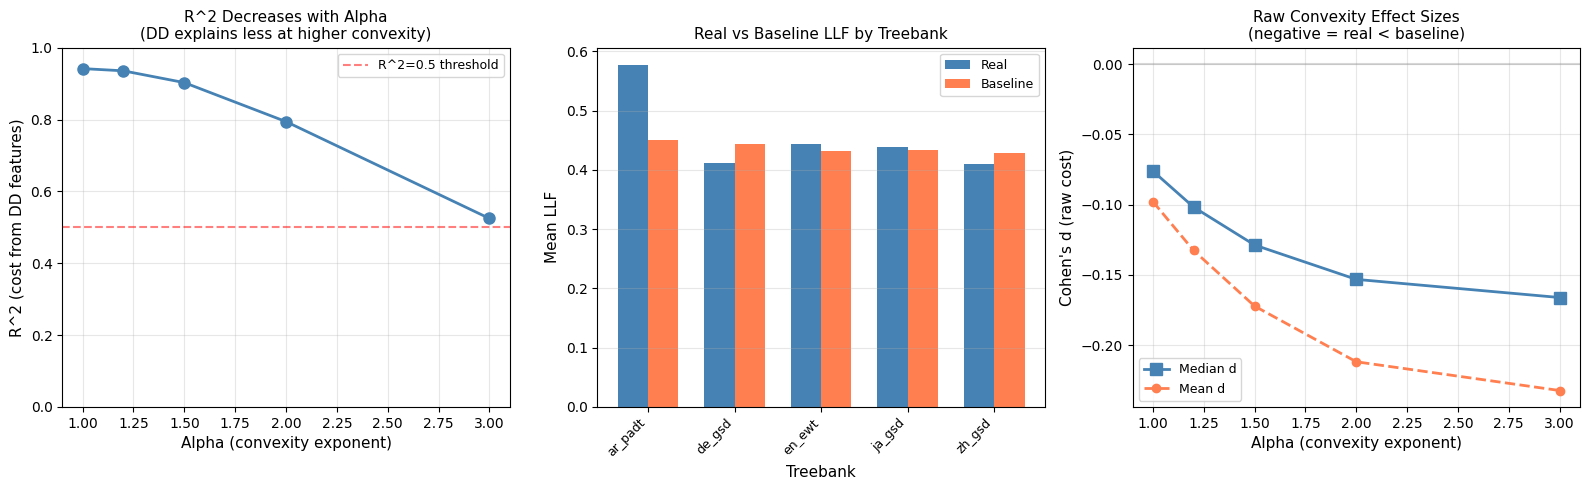

Visualization saved to results_visualization.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: R^2 from DD vs alpha (key monotonicity result) ---
ax = axes[0]
alphas_plot = [a for a, _ in aggregate["convexity_monotonicity"]["r2_by_alpha"]]
r2_plot = [r for _, r in aggregate["convexity_monotonicity"]["r2_by_alpha"]]
ax.plot(alphas_plot, r2_plot, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='R^2=0.5 threshold')
ax.set_xlabel('Alpha (convexity exponent)', fontsize=11)
ax.set_ylabel('R^2 (cost from DD features)', fontsize=11)
ax.set_title('R^2 Decreases with Alpha\n(DD explains less at higher convexity)', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# --- Plot 2: Per-treebank LLF comparison ---
ax = axes[1]
tb_names = [r["treebank_id"] for r in per_tb_final]
real_llfs = [r["stats"]["raw_llf"]["real_mean"] for r in per_tb_final]
base_llfs = [r["stats"]["raw_llf"]["baseline_mean"] for r in per_tb_final]
x_pos = np.arange(len(tb_names))
width = 0.35
ax.bar(x_pos - width/2, real_llfs, width, label='Real', color='steelblue')
ax.bar(x_pos + width/2, base_llfs, width, label='Baseline', color='coral')
ax.set_xlabel('Treebank', fontsize=11)
ax.set_ylabel('Mean LLF', fontsize=11)
ax.set_title('Real vs Baseline LLF by Treebank', fontsize=11)
ax.set_xticks(x_pos)
ax.set_xticklabels(tb_names, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- Plot 3: Raw convexity effect sizes ---
ax = axes[2]
conv_alphas = [ae["alpha"] for ae in aggregate["convexity_raw"]]
conv_median_d = [ae["median_d"] for ae in aggregate["convexity_raw"]]
conv_mean_d = [ae["mean_d"] for ae in aggregate["convexity_raw"]]
ax.plot(conv_alphas, conv_median_d, 's-', color='steelblue', linewidth=2, markersize=8, label='Median d')
ax.plot(conv_alphas, conv_mean_d, 'o--', color='coral', linewidth=2, markersize=6, label='Mean d')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Alpha (convexity exponent)', fontsize=11)
ax.set_ylabel("Cohen's d (raw cost)", fontsize=11)
ax.set_title('Raw Convexity Effect Sizes\n(negative = real < baseline)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("Visualization saved to results_visualization.png")